## 1D Fitting with SASView from notebook
## Peak Voigt single gyroid model

* import all the packages
* install packages before using a separate notebook
* better to work in a dedicated python environnement

* SASView model is a pure python model.
* `porod_peak_voigt_single_gyroid.py`

* to run the notebook, the `porod_peak_voigt_single_gyroid.py` needs to be added here:
`C:\Users\IMPÉROR\CloudStation\dev-SASView\.venv\Lib\site-packages\sasmodels\models`
* It can also run as a plugin model using SASView GUI. To do that, copy it here:
`C:\Users\IMPÉROR\AppData\Local\sasview\SasView\plugin_models`

In [1]:
import numpy as np

import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
from sasmodels.data import plot_theory

from sasmodels.core import load_model_info
from sasmodels.sasview_model import make_model_from_info

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os

* Configuration of matplotlib for plots

In [2]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

### Load a 1D data file

* load an experimental data file .dat
* define here filename and path on your computer

In [3]:
# data file 
filename = "./data-1D/gryneus_1_grid_0088.chi"


Process the data file:
* use `skipheader` to skip the header
* use `skipmin` to skip data points at low q values
  (**important**: `q = 0` makes `(scale_Porod/q)**4 = inf` — always skip it)
* use `skipmax` to skip data points at large q values
* use `slicing_step` to reduce the number of data points
* use `rescale` to convert intensity to cm⁻¹
* use `coeff` to build error bars as a percentage of intensity

total number of data points:  777
after skip at low and large q values: 759
points removed by cleaning (q<=0 / NaN / I<=0): 0
final number of data points: 759
q > 0: True | y > 0: True | dy > 0: True | all finite: True


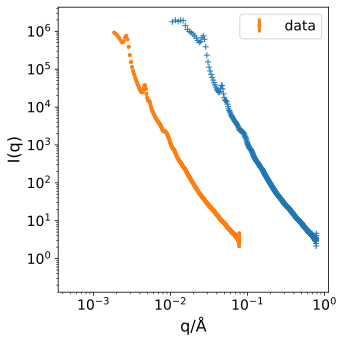

In [4]:
# number of lines in the header
skipheader = 4

# Using loadtxt to load data
data_np = np.loadtxt(filename, skiprows=skipheader)

total_data_number = data_np.shape[0]
print('total number of data points: ', total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

# number of points to skip at low / high q (reference-style trimming)
skipmin = 18
skipmax = 0
number_of_data = total_data_number - skipmax - skipmin
print('after skip at low and large q values:', number_of_data)

# guard: fail loudly if skipmax/skipmin remove everything
if number_of_data <= 0:
    raise ValueError(f'skipmin+skipmax ({skipmin}+{skipmax}) >= data length '
                     f'({total_data_number}); reduce skipmax')

# ---- FAST exploration toggle ----
# True  = quick/approximate run (thinned data, polydispersity off,
#         and prism.py uses a lower Fibonacci count). Flip to False for the final fit.
FAST = True

slicing_step = 1 if FAST else 2   # coarser sampling while exploring

#conversion to A-1 from nm-1
qfactor=0.1

# rescaling of intensity values to cm-1
rescale = 1

# error bars: 10% of intensity values (mirrors reference notebook)
coeff = 0.1

xv = qfactor*data_np[skipmin:skipmin + number_of_data:slicing_step, 0]
yv = rescale * data_np[skipmin:skipmin + number_of_data:slicing_step, 1]
ev = rescale * coeff * abs(data_np[skipmin:skipmin + number_of_data:slicing_step, 1])


mask = np.isfinite(xv) & (xv > 0) & np.isfinite(yv) & (yv > 0) & np.isfinite(ev) & (ev > 0)
xv, yv, ev = xv[mask], yv[mask], ev[mask]
print('points removed by cleaning (q<=0 / NaN / I<=0):', int(np.sum(~mask)))

data = sasmodels.data.Data1D(x=xv, y=yv, dy=ev)
datasub = sasmodels.data.Data1D(x=xv, y=yv, dy=ev)

number_of_data_new = data.x.shape[0]
print('final number of data points:', number_of_data_new)

# safety check — all four MUST be True before fitting
print('q > 0:', bool(np.all(data.x > 0)),
      '| y > 0:', bool(np.all(data.y > 0)),
      '| dy > 0:', bool(np.all(data.dy > 0)),
      '| all finite:', bool(np.all(np.isfinite(data.y)) and np.all(np.isfinite(data.dy))))

sasmodels.data.plot_data(data)

* plot of the new data set `data`

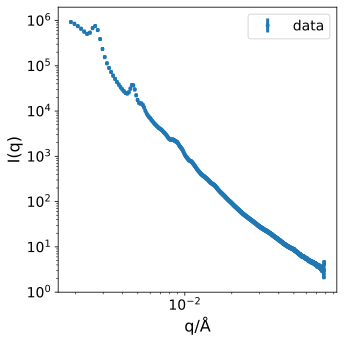

In [5]:
sasmodels.data.plot_data(data)

### save `data` in a new data file
* add `_new` at the end of the name

In [6]:
newfilename = filename[:-4] + '_new.dat'

with open(newfilename, 'w') as f:
    f.write('raw data file is:' + filename + '\n')
    f.write('number of data points: \t' + str(number_of_data_new) + '\n')

with open(newfilename, 'a') as fa:
    for i in range(0, number_of_data_new):
        line_to_write = str(data.x[i]) + '\t' + str(data.y[i]) + '\t' + str(data.dy[i]) + '\n'
        fa.write(line_to_write)

In [7]:
qstart = data.x[0]
print(qstart)

0.0018615860000000001


In [8]:
qend = data.x[number_of_data_new-1]
print(qend)

0.078136301


In [9]:
Istart = data.y[0]
print(Istart)

925772.31


In [10]:
Iend = data.y[number_of_data_new-1]
print(Iend)

4.6423168


### fit the data

* create the computation `kernel` selecting the
  `porod_peak_voigt_single_gyroid` model
* create the `model` interfaced with bumps module
* create the `experiment`, containing both data and model

In [11]:
model_name = "porod_peak_voigt_single_gyroid"

In [12]:
kernel = sasmodels.core.load_model(model_name)
params = {}  # default parameters for now
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

* default values of all parameters

In [13]:
kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'scale_Porod': 0.05,
 'a_cell': 900,
 'w_f': 0.8,
 'hwhm_q110': 0.001,
 'hwhm_q211': 0.001,
 'hwhm_q220': 0.001,
 'hwhm_q310': 0.001,
 'hwhm_q222': 0.001,
 'hwhm_q321': 0.001,
 'hwhm_q400': 0.001,
 'hwhm_q411': 0.001,
 'hwhm_q420': 0.001,
 'hwhm_q332': 0.001,
 'hwhm_q422': 0.001,
 'scale_q110': 1,
 'scale_q211': 1,
 'scale_q220': 1,
 'scale_q310': 1,
 'scale_q222': 1,
 'scale_q321': 1,
 'scale_q400': 1,
 'scale_q411': 1,
 'scale_q420': 1,
 'scale_q332': 1,
 'scale_q422': 1}

#### preliminary step: manual adjustment of parameters before fitting


In [15]:
2*np.pi*np.sqrt(2)/3540

np.float64(0.0025101033548917324)

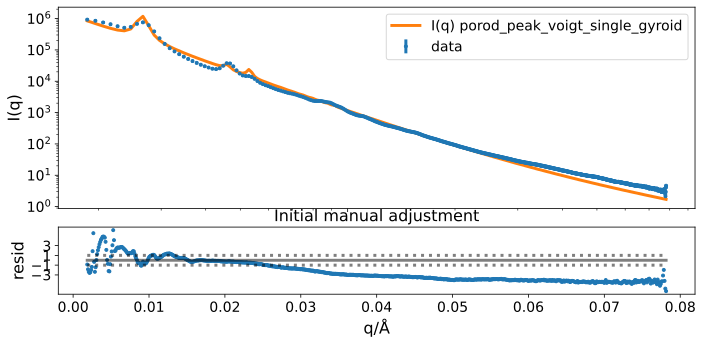

In [22]:
hwhm= 1e-4
params = {
    # --- GLOBAL ---
    "scale": 0.01 , 
    "background": 0.0, 

    # Porod + Hexagonal Peak Voigt, 10 peaks) ---
    "scale_Porod":0.001,
    "a_cell": 3350.,
    "w_f": 0.8,

    "hwhm_q110": hwhm,
    "hwhm_q211": hwhm,
    "hwhm_q220": hwhm,
    "hwhm_q310": hwhm,
    "hwhm_q222": hwhm,
    "hwhm_q321": hwhm,
    "hwhm_q400": hwhm,
    "hwhm_q411": hwhm,
    "hwhm_q420": hwhm,
    "hwhm_q332": hwhm,
    "hwhm_q422": hwhm,

    
    "scale_q110": 1e+8,
    "scale_q211": 1e+6,
    "scale_q220": 1e+6,
    "scale_q310": 1e+4,
    "scale_q222": 1e+4,
    "scale_q321": 1e+4,
    "scale_q400": 1e+4,
    "scale_q411": 1e+4,
    "scale_q420": 1e+4,
    "scale_q332": 1e+4,
    "scale_q422": 1e+4,
    
}


# Build the model and experiment
model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

# Plot the initial guess against your data
plt.figure(figsize=(10, 5))
experiment.plot()
plt.title("Initial manual adjustment")
plt.show()

## fitting the data

* choice of the initial values for parameters
* choice of the fitting parameters with their fitting range

step 1 cost 10.337(36)
                                  a_cell ...|......       3350 in [3000, 4000]
                               hwhm_q110 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q211 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q220 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q222 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q310 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q321 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q332 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q400 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q411 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q420 |.........     0.0001 in [1e-05, 0.001]
                               hwhm_q422 |.........     0.0001 in [1e-05, 0.001]
       

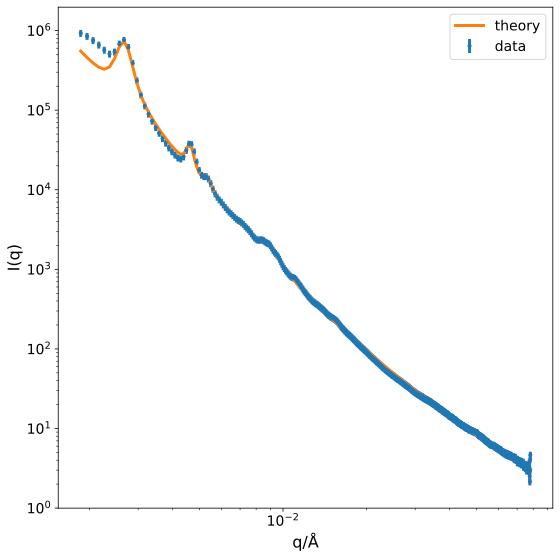

In [28]:
model = sasmodels.bumps_model.Model(model=kernel, **params)

model.scale.range(1e-6,1e+2) 

model.a_cell.range(3000,4000)

#model.w_f.range(0,1)

#model.scale_Porod.range(1e-10 , 100)

model.scale_q110.range(1e-10,1e+10)
model.hwhm_q110.range(1e-5,1e-3)

model.scale_q211.range(1e-10,1e+10)
model.hwhm_q211.range(1e-5,1e-3)

model.scale_q220.range(1e-10,1e+10)
model.hwhm_q220.range(1e-5,1e-3)

model.scale_q310.range(1e-10,1e+10)
model.hwhm_q310.range(1e-5,1e-3)

model.scale_q222.range(1e-10,1e+10)
model.hwhm_q222.range(1e-5,1e-3)

model.scale_q321.range(1e-10,1e+10)
model.hwhm_q321.range(1e-5,1e-3)

model.scale_q400.range(1e-10,1e+10)
model.hwhm_q400.range(1e-5,1e-3)

model.scale_q411.range(1e-10,1e+10)
model.hwhm_q411.range(1e-5,1e-3)

model.scale_q420.range(1e-10,1e+10)
model.hwhm_q420.range(1e-5,1e-3)

model.scale_q332.range(1e-10,1e+10)
model.hwhm_q332.range(1e-5,1e-3)

model.scale_q422.range(1e-10,1e+10)
model.hwhm_q422.range(1e-5,1e-3)


experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, 
                            method='lm', 
                            steps=10, 
                            ftol=1.5e-06, 
                            xtol=1.5e-06, 
                            verbose=True)

plt.figure(figsize=(8,8))
#problem.plot()
print(problem.summarize())
print(model.state())
print(problem.summarize())
print(problem.chisq())
sasmodels.data.plot_theory(data,experiment.Iq_calc)
print(model.state())
print(problem.summarize())
print(problem.chisq())




#### Save the fitted curve in a file
* `_fit` is added at the end of filename

In [29]:

fitfilename = filename[:-4] + '_fit.dat'

with open(fitfilename, 'w') as f:
    f.write('raw data file is:' + filename + '\n')
    f.write('number of data points: \t' + str(number_of_data_new) + '\n')

with open(fitfilename, 'a') as fa:
    for i in range(0, number_of_data_new-1):
        line_to_write = str(data.x[i]) + '\t' + str(experiment.Iq_calc[i]) + '\n'
        fa.write(line_to_write)

### final plot
* use this one for a nice .svg output

0.37841607342542105


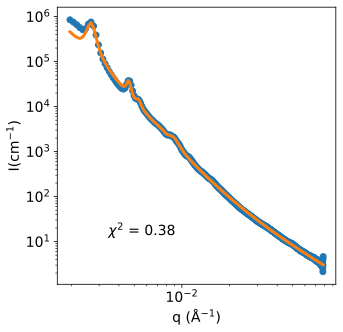

In [30]:

data_final = np.loadtxt(newfilename, skiprows=3)

fit_final = np.loadtxt(fitfilename, skiprows=3)

plt.loglog(data_final[:,0], data_final[:,1], 'o')
plt.loglog(fit_final[:,0], fit_final[:,1])
plt.xlabel('q '+r'(Å$^{-1}$)', fontsize=14)
plt.ylabel('I'+r'(cm$^{-1}$)', fontsize=14)
plt.text(qstart*3, Iend*3, r'$\chi^2$ = '+f"{problem.chisq():.2f}",
         fontsize=14, horizontalalignment='center')
print(problem.chisq())